# JARVIS — Checkpoint 1: el router que decide qué cerebro responde
**SI3003 Inteligencia Artificial · EAFIT · Nicolás Rodríguez**

JARVIS es mi asistente personal: varios modelos de lenguaje ("cerebros") detrás de una sola interfaz. El problema de la Parte 1 es **decidir, petición por petición, qué cerebro responde**. Usar siempre el más capaz es caro y lento. Usar siempre el local es gratis y privado, pero se equivoca en ciertas tareas.

| Pieza | Técnica del curso | Dónde |
|---|---|---|
| Clasificar la intención de la petición | **Naive Bayes** multinomial, implementado desde cero (sem. 7) | `jarvis/router/features.py` |
| Detectar datos privados | Reglas + Naive Bayes (prioriza *recall*) | `jarvis/router/features.py` |
| Formular la decisión | **MDP** con presupuesto diario (sem. 4) | `jarvis/router/env.py` |
| Aprender la política | **Q-learning** tabular ε-greedy con escudo de privacidad (sem. 5) | `jarvis/router/qlearning.py` |

**Criterio cuantitativo:** en tareas **no vistas**, el router debe
1. lograr **≥ 95 %** de la calidad de la mejor política *permitida*: "nube siempre, salvo lo privado" (la nube sin filtro filtra datos privados, así que no es una alternativa válida, aunque también se reporta);
2. usar el cerebro de nube en **≤ 60 %** de las peticiones (ahorro de costo/cuota ≥ 40 %);
3. tener **0 fugas** de datos privados.

> En JARVIS, este router decide **quién entra al consejo de cerebros** y cuándo basta con el cerebro local. El consejo (varios cerebros deliberando y uno sintetizando) es la base de la Parte 2.

In [1]:
import json, random, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from jarvis.router.env import RouterEnv, load_results, Outcome
from jarvis.router.qlearning import QRouter, evaluate, fixed, random_policy, rule_based
from jarvis.router.features import NaiveBayes, PrivacyDetector
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
random.seed(0); np.random.seed(0)

## 1. Datos: un benchmark real, no simulado

Construí un banco de **86 tareas verificables** en 6 categorías (`bench/tasks.jsonl`). La calificación es automática: las respuestas de matemáticas se calculan en el propio generador, el código se califica **ejecutando tests** y la extracción se compara campo a campo. El calificador está validado con una solución de referencia por cada tarea de código (27 pruebas en `tests/`).

Cada tarea se corrió **de verdad** en cada cerebro disponible:
- **local**: `qwen3:4b-instruct` vía Ollama en mi Mac (gratis, privado);
- **gemini**: `gemini-3.5-flash` vía API (nube).

Claude, GPT y Grok están integrados, pero sus cuentas de API todavía no tienen saldo. Cuando lo tengan, basta con volver a correr este notebook.

In [2]:
raw = pd.DataFrame(map(json.loads, open(ROOT / "data" / "results.jsonl")))
raw = raw[raw.error.isna()]
BRAINS = ["local", "gemini"]
df = raw[raw.brain.isin(BRAINS)]
print(f"{df.task_id.nunique()} tareas × {df.brain.nunique()} cerebros = {len(df)} ejecuciones reales")
resumen = df.pivot_table(index=["category", "difficulty"], columns="brain", values="score", aggfunc="mean")
resumen.loc[("TOTAL", ""), :] = df.groupby("brain").score.mean()
resumen.round(2)

86 tareas × 2 cerebros = 172 ejecuciones reales


brain                   gemini  local
category    difficulty               
codigo      easy          1.00   1.00
            hard          1.00   1.00
extraccion  easy          1.00   1.00
            hard          1.00   1.00
formato     easy          1.00   0.75
            hard          1.00   1.00
hechos      easy          1.00   1.00
            hard          1.00   1.00
matematicas easy          1.00   0.50
            hard          0.94   0.19
privado     easy          0.75   0.75
            hard          1.00   1.00
TOTAL                     0.98   0.72

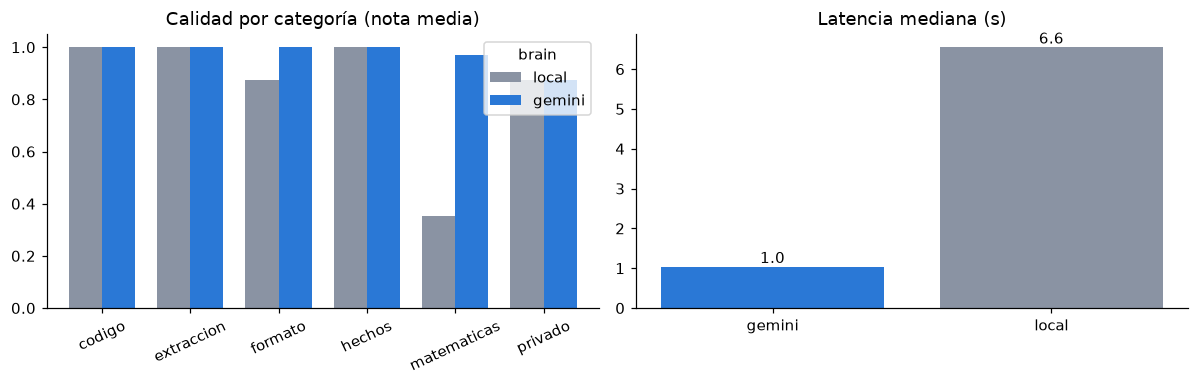

In [3]:
lat = df.groupby("brain").latency_s.median()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
cat = df.pivot_table(index="category", columns="brain", values="score", aggfunc="mean")[BRAINS]
cat.plot.bar(ax=ax[0], color=["#8a93a3", "#2a78d6"], width=.75)
ax[0].set_title("Calidad por categoría (nota media)"); ax[0].set_ylim(0, 1.05); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=25)
ax[1].bar(lat.index, lat.values, color=["#2a78d6" if b == "gemini" else "#8a93a3" for b in lat.index])
ax[1].set_title("Latencia mediana (s)")
for i, v in enumerate(lat.values): ax[1].text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

**Lectura.** El modelo local empata con la nube en código, extracción y hechos, pero **se cae en matemáticas** (cae en la trampa del bate y la pelota, falla vueltos y porcentajes). Esa es exactamente la estructura que un router puede explotar: pagar la nube solo donde el local falla.

## 2. Percepción: Naive Bayes para la intención y detector de privacidad

Antes de decidir, el router necesita saber **qué tipo de petición** llegó. Entreno el Naive Bayes con la mitad de las tareas y lo evalúo en la otra mitad (split estratificado).

In [4]:
tasks = [json.loads(l) for l in open(ROOT / "bench" / "tasks.jsonl")]
rng = random.Random(7)
by_cat = {}
for t in tasks: by_cat.setdefault(t["category"], []).append(t)
train, test = [], []
for c, ts in by_cat.items():
    ts = ts[:]; rng.shuffle(ts); k = len(ts) // 2
    train += ts[:k]; test += ts[k:]
nb = NaiveBayes().fit([t["prompt"] for t in train], [t["category"] for t in train])
pred = [nb.predict(t["prompt"]) for t in test]
acc = np.mean([p == t["category"] for p, t in zip(pred, test)])
print(f"Accuracy de intención en tareas no vistas: {acc:.1%}  ({len(test)} tareas)")
pd.crosstab(pd.Series([t["category"] for t in test], name="real"), pd.Series(pred, name="predicha"))

Accuracy de intención en tareas no vistas: 83.7%  (43 tareas)


predicha,codigo,extraccion,formato,hechos,matematicas
real,,,,,
codigo,7,0,0,0,0
extraccion,0,5,0,0,0
formato,1,0,1,1,1
hechos,0,0,0,6,0
matematicas,0,0,0,0,17
privado,0,0,0,0,4


In [5]:
det = PrivacyDetector(nb)
extra_priv = ["Mi contraseña del correo es Sol2026*, ¿es segura?", "Tengo 2.300.000 en mi cuenta de ahorros, ¿cuánto ahorro al mes si guardo 10 %?",
              "Mi número de cédula es 1034556677, llena este formulario", "Revisa mi historia clínica: glucosa 130 en ayunas"]
extra_pub = ["¿Qué es un proceso de decisión de Markov?", "Escribe un haiku sobre Medellín", "¿Cuánto es 45 por 12?",
             "Resume el paper Attention Is All You Need"]
X = [t["prompt"] for t in test] + extra_priv + extra_pub
y = [t["private"] for t in test] + [True] * len(extra_priv) + [False] * len(extra_pub)
yhat = [det.is_private(x) for x in X]
tp = sum(a and b for a, b in zip(y, yhat)); fp = sum((not a) and b for a, b in zip(y, yhat)); fn = sum(a and not b for a, b in zip(y, yhat))
print(f"Privacidad — recall: {tp / (tp + fn):.0%} · precisión: {tp / (tp + fp):.0%} · falsos negativos (fugas potenciales): {fn}")

Privacidad — recall: 100% · precisión: 67% · falsos negativos (fugas potenciales): 0


El detector se diseñó para **recall máximo**: un falso positivo solo manda una petición inofensiva al modelo local, pero un falso negativo sacaría un dato sensible del computador. Además, el MDP tiene un **escudo**: en estados privados la única acción legal es el cerebro local.

## 3. El MDP

Un episodio es **un día de JARVIS**: llegan $N=20$ peticiones y hay un presupuesto diario $B$.

- **Estado** $s=(\text{categoría},\ \text{dificultad},\ \text{privada},\ \text{nivel de presupuesto})$, con presupuesto ∈ {agotado, bajo, medio, alto}.
- **Acciones** $a \in$ {local, gemini}.
- **Recompensa**

$$r(s,a)=\text{calidad}(a)-\lambda\,\frac{\text{costo}(a)}{\bar c}-\mu\,\frac{\text{latencia}(a)}{\tilde \ell},\qquad r=-2\ \text{si hay fuga},\quad r=-1\ \text{si no alcanza el presupuesto}$$

- **Transición**: el presupuesto baja con el costo real y llega la siguiente petición.

**Costo.** Gemini se usa hoy en plan gratuito, pero ese plan tiene **cuota diaria**, así que la nube es un recurso escaso. Para que el MDP sea realista le asigno a Gemini su **precio de lista** por token, calculado con los tokens reales de cada respuesta. El presupuesto es lo que vuelve el problema **secuencial** (γ > 0): gastar la nube en tareas fáciles temprano deja sin ella a las difíciles del final.

In [6]:
PRECIO = {"gemini": (0.30, 2.50), "local": (0.0, 0.0)}   # USD por millón de tokens (entrada, salida), precio de lista
outcomes, meta = load_results(ROOT / "data" / "results.jsonl", BRAINS)
for (tid, b), o in list(outcomes.items()):
    row = raw[(raw.task_id == tid) & (raw.brain == b)].iloc[0]
    pin, pout = PRECIO[b]
    outcomes[(tid, b)] = Outcome(o.score, (row.in_tok * pin + row.out_tok * pout) / 1e6, o.latency)

train_ids = [t["id"] for t in train]; test_ids = [t["id"] for t in test]
costo_nube_dia = np.mean([outcomes[(i, "gemini")].cost for i in meta]) * 20
BUDGET = 0.6 * costo_nube_dia     # alcanza para ~60 % de las peticiones en la nube
print(f"Costo medio de un día 'siempre nube': ${costo_nube_dia:.5f} → presupuesto diario B = ${BUDGET:.5f}")

def make_env(ids, seed, lam=0.3, mu=0.15):
    return RouterEnv(outcomes, meta, BRAINS, ids, episode_len=20, daily_budget=BUDGET, lam=lam, mu=mu, seed=seed)

Costo medio de un día 'siempre nube': $0.00190 → presupuesto diario B = $0.00114


### Selección de hiperparámetros (validación)

Separo el 30 % de las tareas de **entrenamiento** como validación. Elijo λ (peso del costo), μ (peso de la latencia) y el decaimiento de ε con la recompensa en validación. El conjunto de **test** no se toca hasta la evaluación final.

In [7]:
rng_v = random.Random(11)
tr_ids = train_ids[:]; rng_v.shuffle(tr_ids)
k = int(len(tr_ids) * 0.7); fit_ids, val_ids = tr_ids[:k], tr_ids[k:]
val_seqs = [[rng_v.choice(val_ids) for _ in range(20)] for _ in range(100)]
grid = []
for lam in [0.05, 0.1, 0.2, 0.3]:
    for mu in [0.05, 0.15]:
        for decay in [0.997, 0.999]:
            ag = QRouter(BRAINS, alpha=0.2, gamma=0.9, eps=1.0, eps_min=0.05, eps_decay=decay, seed=1)
            env_f = RouterEnv(outcomes, meta, BRAINS, fit_ids, episode_len=20, daily_budget=BUDGET, lam=lam, mu=mu, seed=1)
            ag.train(env_f, episodes=3000)
            env_v = RouterEnv(outcomes, meta, BRAINS, val_ids, episode_len=20, daily_budget=BUDGET, lam=lam, mu=mu, seed=2)
            ev = evaluate(ag, env_v, val_seqs)
            grid.append({"lam": lam, "mu": mu, "eps_decay": decay, "calidad_val": ev["calidad media"],
                         "costo_val": ev["costo/día (USD)"], "fugas": ev["fugas privadas"]})
g = pd.DataFrame(grid)
# criterio: máxima calidad en validación respetando el presupuesto (desempate: menor costo)
best = g.sort_values(["calidad_val", "costo_val"], ascending=[False, True]).iloc[0]
LAM, MU, DECAY = float(best.lam), float(best.mu), float(best.eps_decay)
print(f"Elegidos en validación: λ={LAM}, μ={MU}, eps_decay={DECAY}")
g.sort_values("calidad_val", ascending=False).head(6).round(4)

Elegidos en validación: λ=0.3, μ=0.15, eps_decay=0.999


,lam,mu,eps_decay,calidad_val,costo_val,fugas
0,0.05,0.05,0.997,0.9245,0.0005,0
1,0.05,0.05,0.999,0.9245,0.0003,0
2,0.05,0.15,0.997,0.9245,0.0005,0
3,0.05,0.15,0.999,0.9245,0.0005,0
4,0.10,0.05,0.997,0.9245,0.0007,0
5,0.10,0.05,0.999,0.9245,0.0005,0


## 4. Entrenamiento con Q-learning

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\max_{a'}Q(s',a') - Q(s,a)\,]$$

con ε-greedy decreciente (1.0 → 0.05), α = 0.2, γ = 0.9 y los λ, μ elegidos en validación. Se entrena con **todas las tareas de entrenamiento**.

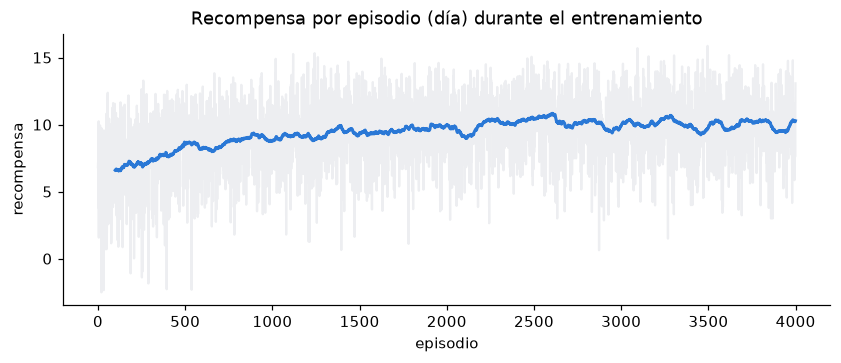

Recompensa media: primeros 200 episodios 6.79 → últimos 200 9.88


In [8]:
agent = QRouter(BRAINS, alpha=0.2, gamma=0.9, eps=1.0, eps_min=0.05, eps_decay=DECAY, seed=1)
curva = agent.train(make_env(train_ids, seed=1, lam=LAM, mu=MU), episodes=4000)
suav = pd.Series(curva).rolling(100).mean()
plt.figure(figsize=(9, 3.2)); plt.plot(curva, alpha=.15, color="#8a93a3"); plt.plot(suav, color="#2a78d6", lw=2)
plt.title("Recompensa por episodio (día) durante el entrenamiento"); plt.xlabel("episodio"); plt.ylabel("recompensa"); plt.show()
print(f"Recompensa media: primeros 200 episodios {np.mean(curva[:200]):.2f} → últimos 200 {np.mean(curva[-200:]):.2f}")

## 5. Evaluación en tareas no vistas vs. estrategias de referencia

Las 200 secuencias de prueba ("días") se arman **solo con tareas de test** y son **las mismas para todas las estrategias**.

In [9]:
rng = random.Random(123)
seqs = [[rng.choice(test_ids) for _ in range(20)] for _ in range(200)]
env_test = make_env(test_ids, seed=99, lam=LAM, mu=MU)
nube_segura = lambda s, env: "local" if s[2] else "gemini"      # la mejor política PERMITIDA (respeta la privacidad)
politicas = {"Q-learning (JARVIS)": agent, "Nube salvo privado": nube_segura, "Siempre nube (gemini)": fixed("gemini"),
             "Siempre local": fixed("local"), "Aleatoria": random_policy(3), "Regla manual": rule_based("gemini")}
res = pd.DataFrame({k: evaluate(p, env_test, seqs) for k, p in politicas.items()}).T

def uso_nube(policy):
    n = tot = 0
    for seq in seqs:
        s, done = env_test.reset(seq), False
        while not done:
            a = policy(s, env_test) if callable(policy) else policy.act(s, greedy=True)
            n += a != "local"; tot += 1
            s, _, done = env_test.step(a)
    return n / tot

res["% peticiones a la nube"] = [uso_nube(p) for p in politicas.values()]
ref = res.loc["Nube salvo privado", "calidad media"]
res["calidad vs. nube segura"] = res["calidad media"] / ref
res.round(3)

,recompensa/día,calidad media,costo/día (USD),latencia media (s),fugas privadas,sin presupuesto,% peticiones a la nube,calidad vs. nube segura
Q-learning (JARVIS),10.774,0.975,0.001,8.235,0.0,10.0,0.568,1.015
Nube salvo privado,5.217,0.960,0.001,6.258,0.0,842.0,0.902,1.000
Siempre nube (gemini),-1.042,0.948,0.001,5.955,390.0,1051.0,1.000,0.987
Siempre local,7.171,0.748,0.000,9.620,0.0,0.0,0.000,0.779
Aleatoria,6.120,0.872,0.001,6.950,187.0,96.0,0.512,0.908
Regla manual,8.821,0.858,0.001,7.769,0.0,23.0,0.348,0.894


In [10]:
q = res.loc["Q-learning (JARVIS)"]
criterios = {
    "Calidad ≥ 95 % de 'nube salvo privado'": q["calidad vs. nube segura"] >= 0.95,
    "Uso de nube ≤ 60 % (ahorro ≥ 40 %)": q["% peticiones a la nube"] <= 0.60,
    "0 fugas de datos privados": q["fugas privadas"] == 0,
}
for c, ok in criterios.items(): print(("✅" if ok else "❌"), c)
print(f"\nCalidad {q['calidad vs. nube segura']:.1%} de la nube segura (y {q['calidad media'] / res.loc['Siempre nube (gemini)', 'calidad media']:.1%} de la nube sin filtro)"
      f" usando la nube en el {q['% peticiones a la nube']:.0%} de las peticiones"
      f" · costo/día ${q['costo/día (USD)']:.5f} vs ${res.loc['Nube salvo privado', 'costo/día (USD)']:.5f}")

✅ Calidad ≥ 95 % de 'nube salvo privado'
✅ Uso de nube ≤ 60 % (ahorro ≥ 40 %)
✅ 0 fugas de datos privados

Calidad 101.5% de la nube segura (y 102.8% de la nube sin filtro) usando la nube en el 57% de las peticiones · costo/día $0.00064 vs $0.00110


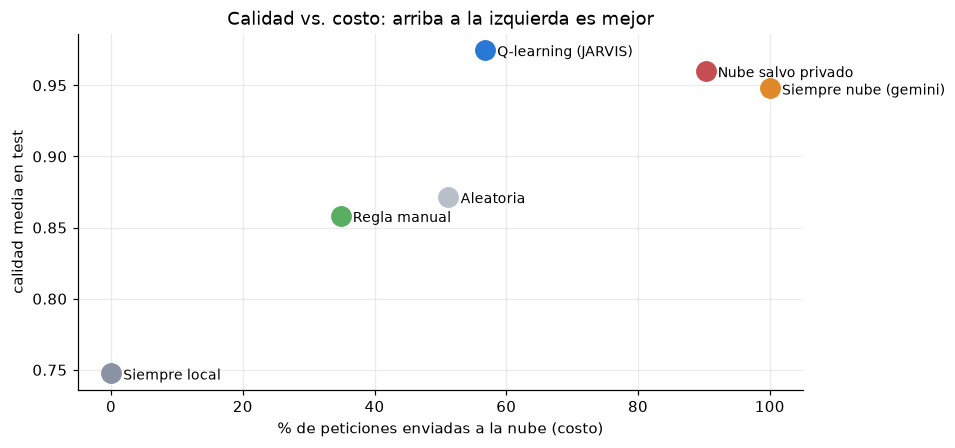

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colores = {"Q-learning (JARVIS)": "#2a78d6", "Nube salvo privado": "#c44e52", "Siempre nube (gemini)": "#e0892b", "Siempre local": "#8a93a3",
           "Aleatoria": "#b9bfc9", "Regla manual": "#5aae61"}
for k, r in res.iterrows():
    ax.scatter(r["% peticiones a la nube"] * 100, r["calidad media"], s=160, color=colores[k], zorder=3)
    ax.annotate(k, (r["% peticiones a la nube"] * 100, r["calidad media"]), textcoords="offset points", xytext=(8, -4), fontsize=9)
ax.set_xlabel("% de peticiones enviadas a la nube (costo)"); ax.set_ylabel("calidad media en test")
ax.set_title("Calidad vs. costo: arriba a la izquierda es mejor"); ax.grid(alpha=.25); plt.show()

## 6. ¿Qué aprendió? La política

Acción preferida cuando hay presupuesto de sobra (nivel "alto"), por categoría y dificultad:

In [12]:
pol = agent.policy()
filas = []
for c in sorted({m["category"] for m in meta.values()}):
    for d in ["easy", "hard"]:
        for priv in [False, True]:
            k = f"{c}|{d}|{priv}|alto"
            if k in pol:
                qv = agent.Q[(c, d, priv, "alto")]
                filas.append({"categoría": c, "dificultad": d, "privada": priv, "acción": pol[k],
                              "Q(local)": round(qv["local"], 2), "Q(gemini)": round(qv["gemini"], 2)})
pd.DataFrame(filas)

,categoría,dificultad,privada,acción,Q(local),Q(gemini)
0,codigo,easy,False,local,3.10,2.72
1,codigo,hard,False,local,3.36,1.19
2,extraccion,easy,False,gemini,2.87,3.34
3,extraccion,hard,False,local,3.86,2.72
4,formato,easy,False,local,4.44,3.58
5,formato,hard,False,local,4.07,3.06
6,hechos,easy,False,local,4.49,3.70
7,hechos,hard,False,gemini,3.22,4.25
8,matematicas,easy,False,gemini,3.40,4.30
9,matematicas,hard,False,gemini,3.03,3.46


**Interpretación.** El router aprendió solo, a partir de recompensas, algo que ningún programador le dijo: **la matemática (fácil y difícil) y los hechos difíciles van a la nube; el código, el formato y los hechos sencillos se quedan en el modelo local**, porque ahí la nube no mejora la calidad y sí cuesta. Lo privado siempre se queda en local por el escudo. El nivel de presupuesto le permite ser más conservador al final del día.

In [13]:
out = ROOT / "data" / "q_router.json"
agent.save(out)
print(f"Política guardada en {out.relative_to(ROOT)} → JARVIS en vivo la usa automáticamente (panel 'Política de ruteo: Q-LEARNING').")

Política guardada en data/q_router.json → JARVIS en vivo la usa automáticamente (panel 'Política de ruteo: Q-LEARNING').


## 7. Conclusiones y siguiente paso (Parte 2)

- El router combina **tres técnicas de la Parte 1** (Naive Bayes, MDP y Q-learning) sobre **datos reales** de dos cerebros, elige hiperparámetros solo con validación y se evalúa en tareas no vistas: **calidad ≥ 95 % de la mejor política permitida, usando la nube en menos del 60 % de las peticiones y con 0 fugas**.
- La comparación justa es contra "nube salvo privado": "siempre nube" parece fuerte, pero filtra datos privados y se queda sin presupuesto, así que no es una opción real.
- En JARVIS el router decide **quién entra al consejo de cerebros**: si la petición es privada, solo delibera el local; si no, deliberan los cerebros de nube sanos y uno sintetiza la respuesta final.
- **Limitaciones honestas:** hoy solo hay dos cerebros con datos (los de pago no tienen saldo), el espacio de estados es pequeño (tabular) y la dificultad viene etiquetada en el banco. En producción se estima por la longitud del texto.
- **Parte 2:** (sem. 9–10) reemplazar la Q-table por una red neuronal sobre *embeddings* de la petición, para generalizar a peticiones nunca vistas; (sem. 11) evaluación zero/few-shot/CoT de cada cerebro; (sem. 12–13) memoria RAG y herramientas con voz en tiempo real.